# [ Computer Vision ] [ CSE445 ] [ Assignment-1 ]
**Dataset Name:** IoTKITs<br>
**Source Link:** https://data.mendeley.com/datasets/x5thzmkxhy/1

## Configuration

In [1]:
import os
import json
import pandas as pd

dataset_dir = "/kaggle/input/datasets/Mrpaul0007/32-v1i-coco"
train_dir = os.path.join(dataset_dir, "train")
valid_dir = os.path.join(dataset_dir, "valid")

train_annotation = os.path.join(train_dir, "_annotations.coco.json")
valid_annotation = os.path.join(valid_dir, "_annotations.coco.json")

working_dir = "/kaggle/working/"
split_dir = os.path.join(working_dir, "splits")
visualizations_dir = os.path.join(working_dir, "visualizations")

for directory in [split_dir, visualizations_dir]:
    os.makedirs(directory, exist_ok = True)

def annotation_format(train, valid):
    if train.endswith(".json") and valid.endswith(".json"):
        return "COCO Format (.json)"
    elif train.endswith(".xml") and valid.endswith(".xml"):
        return "Pascal VOC Format (.xml)"
    elif train.endswith(".txt") and valid.endswith(".txt"):
        return "YOLO Format (.txt)"
    else:
        return "Unknown Format / Multiple Formats"


def image_size(path):
    with open(path, "r") as f:
        data = json.load(f)
        image_sizes = {f"{img['width']}x{img['height']}" for img in data["images"]}

        if len(image_sizes) == 1:
            return f"{list(image_sizes)[0]} [All images are same size]"

        else:
            return "Multiple sizes found!"


def class_name(path):
    class_list = []
    with open(path, "r") as f:
        data = json.load(f)

        if "categories" in data:
            for category in data["categories"]:
                class_list.append({"Id": category["id"], "Name": category["name"]})
            df = pd.DataFrame(class_list).sort_values("Id").reset_index(drop=True)
            return df
        else:
            return "No Categories Found!"

train_ratio = 0.80
validation_ratio = 0.10
test_ratio = 0.10


print("====== Configuration ======")
print("\nDataset Paths:\n")
print("Dataset_path",dataset_dir)
print("Train_path",train_dir)
print("Valid_path",valid_dir)
print("Train_Annotation_path",train_annotation)
print("Valid_Annotation_path",valid_annotation)
print("Anotation Format:",annotation_format(train_annotation, valid_annotation))
print("\nImage Size:")
print("Train Image Size:", image_size(train_annotation))
print("Valid Image Size:", image_size(valid_annotation))
print("\nTarget Split Ratio:")
print("Train Ratio:",train_ratio)
print("Validation Ratio:",validation_ratio)
print("Test Ratio:",test_ratio)
print("\nClass Names with ID:")
print("Train_Annotation_Class_name:")
display(class_name(train_annotation).style.hide(axis="index"))
print("Valid_Annotation_Class_name:")
display(class_name(valid_annotation).style.hide(axis="index"))
print("\nConfiguration Loaded Successfully!")

====== Configuration ======

Dataset Paths:

Dataset_path /kaggle/input/datasets/Mrpaul0007/32-v1i-coco
Train_path /kaggle/input/datasets/Mrpaul0007/32-v1i-coco/train
Valid_path /kaggle/input/datasets/Mrpaul0007/32-v1i-coco/valid
Train_Annotation_path /kaggle/input/datasets/Mrpaul0007/32-v1i-coco/train/_annotations.coco.json
Valid_Annotation_path /kaggle/input/datasets/Mrpaul0007/32-v1i-coco/valid/_annotations.coco.json
Anotation Format: COCO Format (.json)

Image Size:
Train Image Size: 640x640 [All images are same size]
Valid Image Size: 640x640 [All images are same size]

Target Split Ratio:
Train Ratio: 0.8
Validation Ratio: 0.1
Test Ratio: 0.1

Class Names with ID:
Train_Annotation_Class_name:


Id,Name
0,esp8266-new3-13-Wemos-e-zero-mega-3B-3B--final-ESP32-STM32-Arduino-Esp32-33-new3-13-Wemos-e-zero-mega-3B-3B--final-ESP32-STM32-Arduino-Esp32-33-vI0n
1,Arduino Mega 2560 -Black-
2,Arduino Mega 2560 -Blue-
3,Arduino Mega 2560 -Yellow-
4,Arduino Uno -Black-
5,Arduino Uno -Green-
6,Arduino Uno Camera Shield
7,Arduino Uno WiFi Shield
8,Arduino-Due
9,Arduino-Micro


Valid_Annotation_Class_name:


Id,Name
0,esp8266-new3-13-Wemos-e-zero-mega-3B-3B--final-ESP32-STM32-Arduino-Esp32-33-new3-13-Wemos-e-zero-mega-3B-3B--final-ESP32-STM32-Arduino-Esp32-33-vI0n
1,Arduino Mega 2560 -Black-
2,Arduino Mega 2560 -Blue-
3,Arduino Mega 2560 -Yellow-
4,Arduino Uno -Black-
5,Arduino Uno -Green-
6,Arduino Uno Camera Shield
7,Arduino Uno WiFi Shield
8,Arduino-Due
9,Arduino-Micro



Configuration Loaded Successfully!


## Dataset Integrity Check

In [2]:
from PIL import Image

def load_coco(path):
    with open(path, "r") as f:
        return json.load(f)

def check(name, directory, path):
    print(f"Checking {name} Split")
    print("-"*20)
    coco = load_coco(path)
    img = coco["images"]
    annotation = coco["annotations"]
    cats = {}
    for c in coco["categories"]:
        iD = c["id"] 
        name = c["name"]
        cats[iD] = name
        
    print("\nFile Count:")
    print(f"Images: {len(img)}")
    print(f"Annotations: {len(annotation)}")
    print(f"Categories: {len(cats)}")

    missing_files = []
    corrupt_files = []
    dimension_mismatch_files = []

    img_with_id = {}
    for pic in img:
        img_with_id[pic["id"]] = pic
        
    for pic in img:
        path = os.path.join(directory, pic["file_name"])
        if not os.path.exists(path):
            missing_files.append(pic["file_name"])
            continue
        try:
            with Image.open(path) as IMG:
                IMG.verify()
            with Image.open(path) as IMG:
                w, h = IMG.size
            if (w, h) != (pic["width"], pic["height"]):
                dimension_mismatch_files.append((pic["file_name"], (w, h), (pic["width"], pic["height"])))
        except Exception as e:
            corrupt_files.append((pic["file_name"], str(e)))
    wrong_boxes = []
    unknown_category = []

    annotation_per_img = {}
    for a in annotation:
        img_id = a["image_id"]
        if img_id in annotation_per_img:
            annotation_per_img[img_id] = annotation_per_img[img_id] + 1
        else:
            annotation_per_img[img_id] = 1

    for a in annotation:
        x, y, bw, bh = a["bbox"]
        pic = img_with_id.get(a["image_id"])
        
        if pic is None:
            wrong_boxes.append(f"{a['id']} is an orphan annotation,  there is no matching with image_id")
            continue
        if x < 0 or y < 0 or bw <= 0 or bh <= 0 or x+bw > pic["width"] + 1 or y+bh > pic["height"] + 1:
            wrong_boxes.append((a["id"], f"bbox = {a['bbox']} vs Image size {a['width']}x{a['height']}"))
        if a["category_id"] not in cats:
            unknown_category.append((a["id"], a["file_name"]))

    no_annotation = []
    for i in img:
        img_id = i["id"]
        img_name = i["file_name"]
        
        if annotation_per_img.get(img_id, 0) == 0:
            no_annotation.append(f"{img_id}   {img_name}")

    print("\nMissing, Corrupt & Dimension Mismatch:")
    print(f"Missing Files: {len(missing_files)}") 
    print(f"Corrupt Files: {len(corrupt_files)}")
    print(f"Dimension Mismatch Files: {len(dimension_mismatch_files)}") 

    print("\nFormat Consistency:")
    print(f"Wrong Boxes: {len(wrong_boxes)}") 
    print(f"Unknown Category: {len(unknown_category)}") 
    print(f"0 Annotation: {len(no_annotation)}") 

train_repo =  check("Train", train_dir, train_annotation)
print("\n")
vaild_repo = check("Valid", valid_dir, valid_annotation)

Checking Train Split
--------------------

File Count:
Images: 2488
Annotations: 2615
Categories: 33

Missing, Corrupt & Dimension Mismatch:
Missing Files: 0
Corrupt Files: 0
Dimension Mismatch Files: 0

Format Consistency:
Wrong Boxes: 0
Unknown Category: 0
0 Annotation: 1


Checking Valid Split
--------------------

File Count:
Images: 620
Annotations: 651
Categories: 33

Missing, Corrupt & Dimension Mismatch:
Missing Files: 0
Corrupt Files: 0
Dimension Mismatch Files: 0

Format Consistency:
Wrong Boxes: 0
Unknown Category: 0
0 Annotation: 0


## EDA

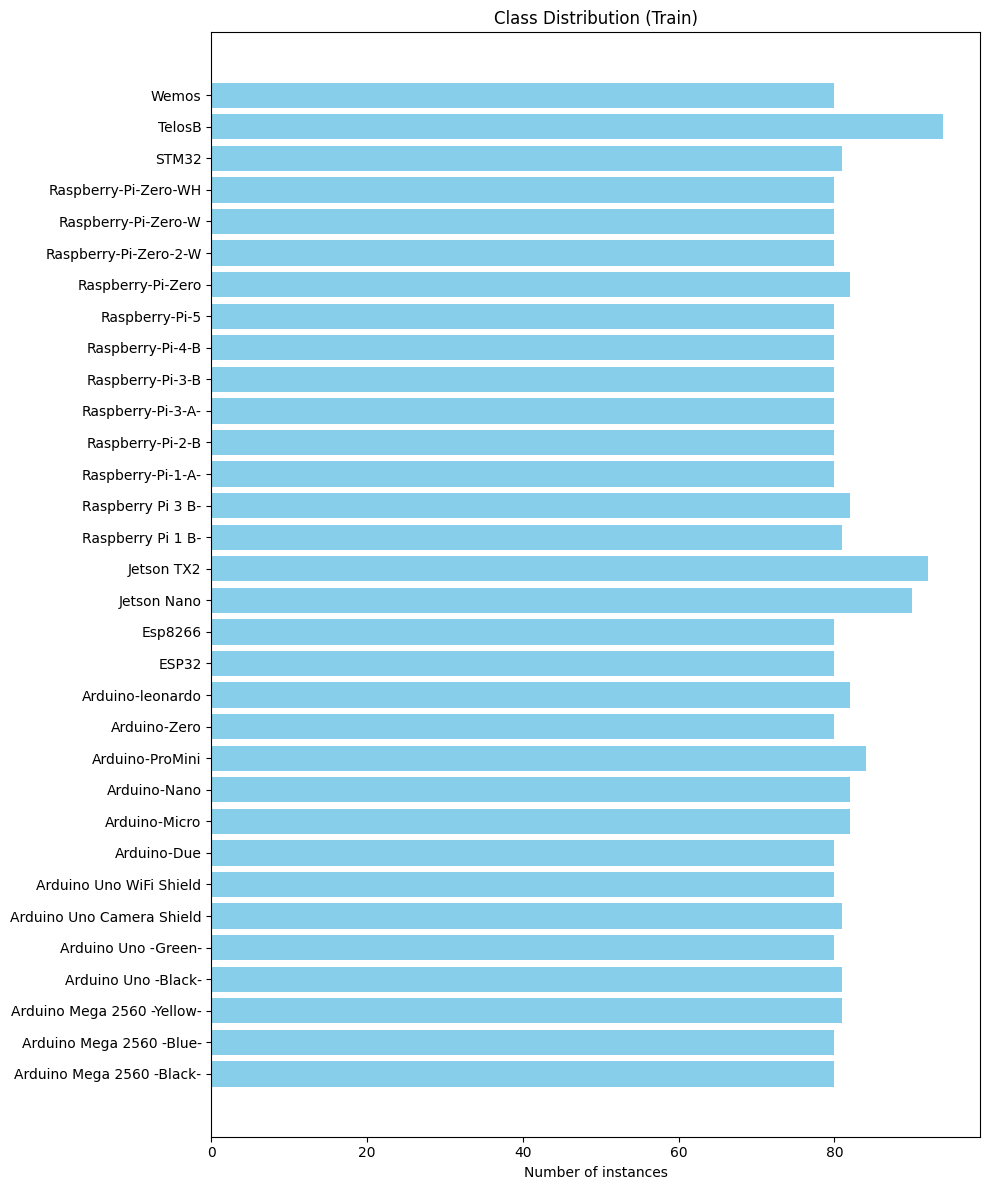

[Train] class count -> max=94, min=80, imbalance ratio=1.18x -> roughly balanced (ratio <= 3x)


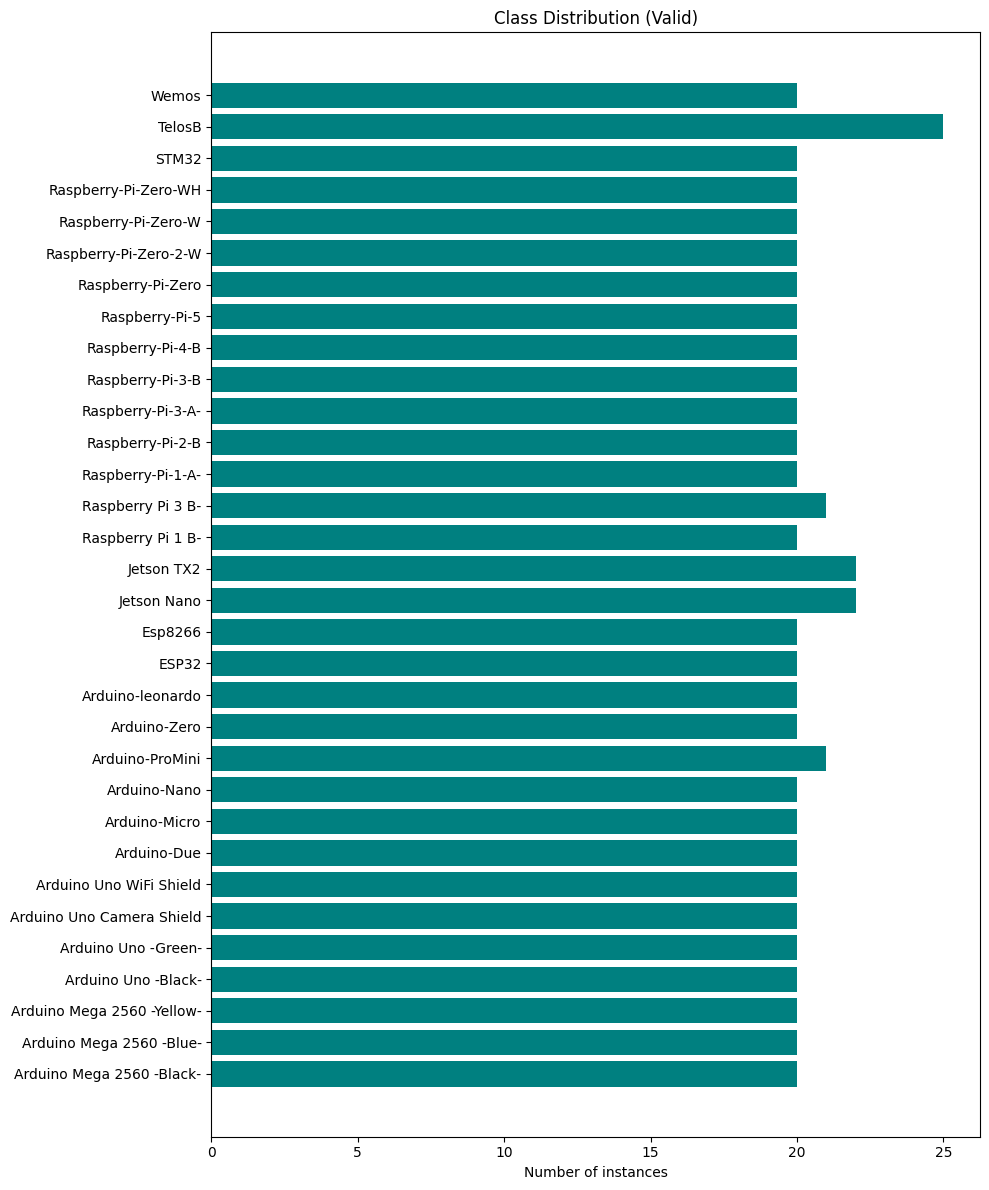

[Valid] class count -> max=25, min=20, imbalance ratio=1.25x -> roughly balanced (ratio <= 3x)


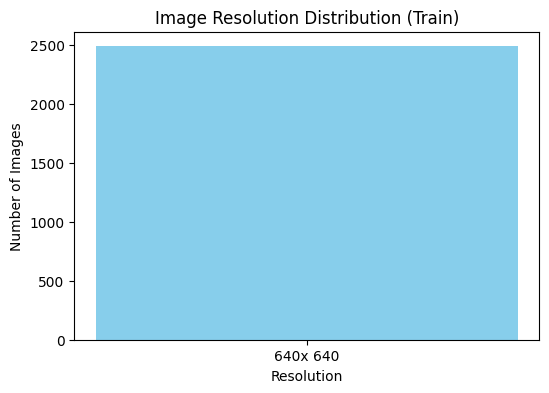

[Train] aspect ratio (w/h): min=1.00  max=1.00  (unique values: 1)
[Train] file formats: {'jpg': 2488}


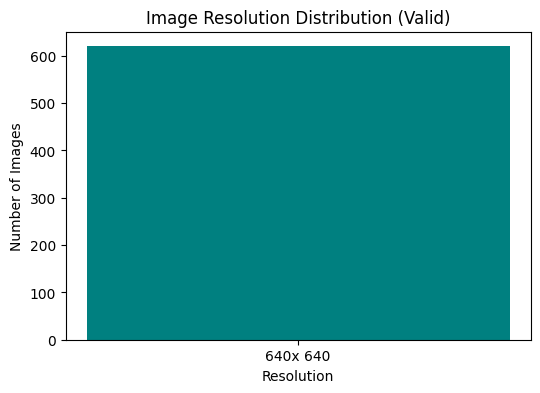

[Valid] aspect ratio (w/h): min=1.00  max=1.00  (unique values: 1)
[Valid] file formats: {'jpg': 620}


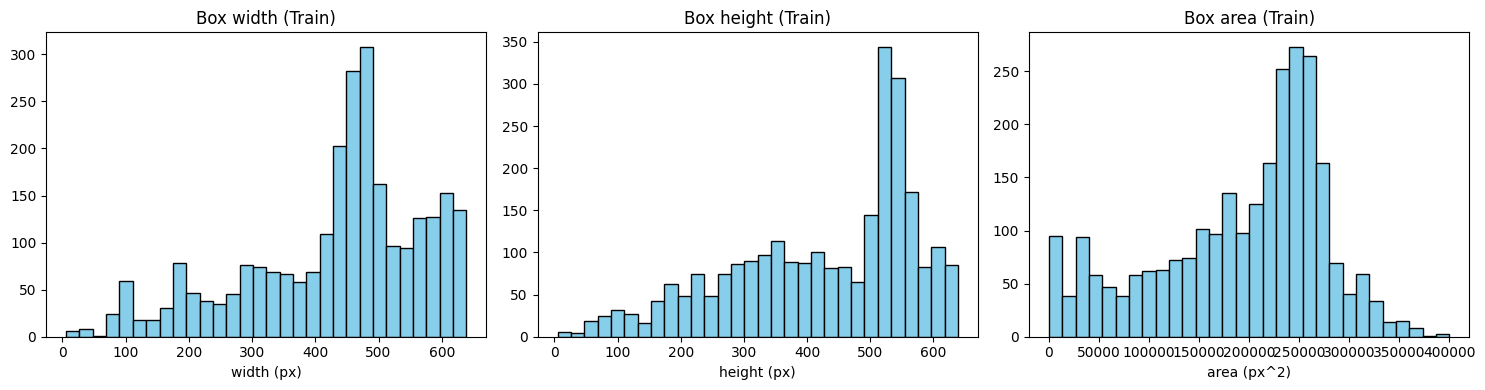

[Train] width  : min=6.0  median=464.0  max=639.0
[Train] height : min=5.0  median=470.0  max=639.0
[Train] area   : min=30.0  median=217668.0  max=400087.7
[Train] boxes per image : min=0  mean=1.05  max=3
[Train] object size split -> small(<32^2)=6 (0.2%)  medium(32^2-96^2)=69 (2.6%)  large(>96^2)=2540 (97.1%)


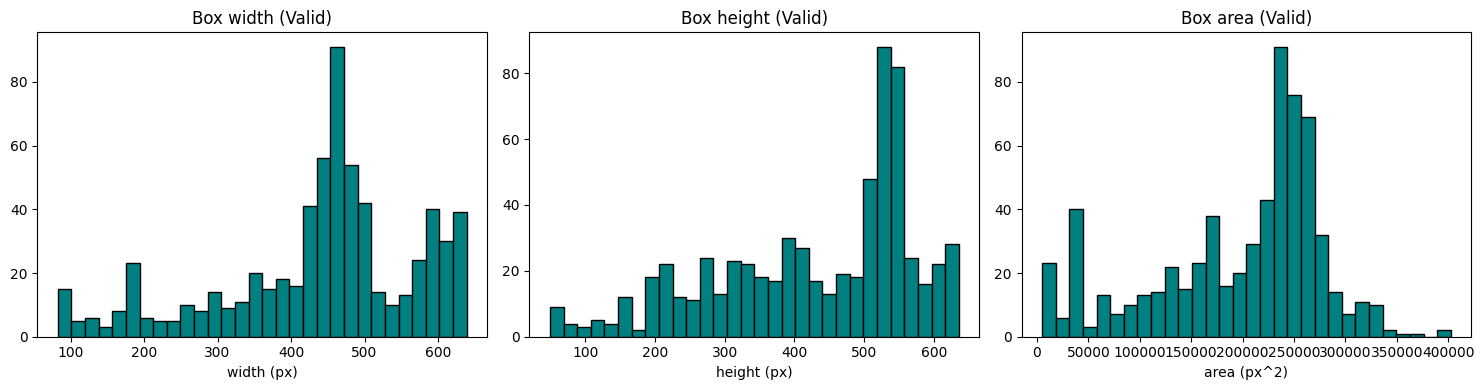

[Valid] width  : min=82.7  median=461.0  max=639.0
[Valid] height : min=49.0  median=481.0  max=636.0
[Valid] area   : min=4928.0  median=227115.0  max=402590.0
[Valid] boxes per image : min=1  mean=1.05  max=2
[Valid] object size split -> small(<32^2)=0 (0.0%)  medium(32^2-96^2)=13 (2.0%)  large(>96^2)=638 (98.0%)


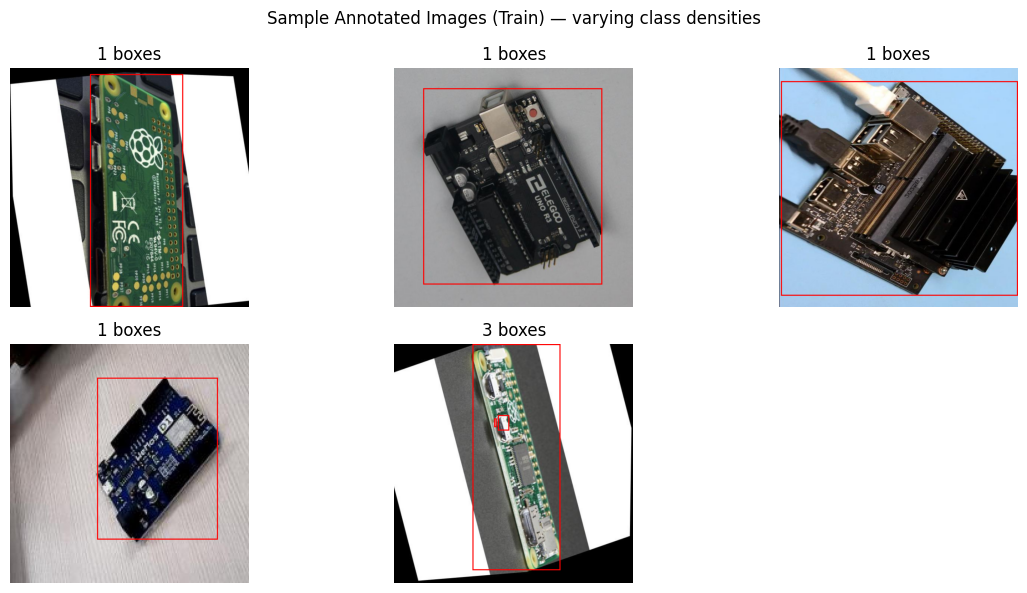

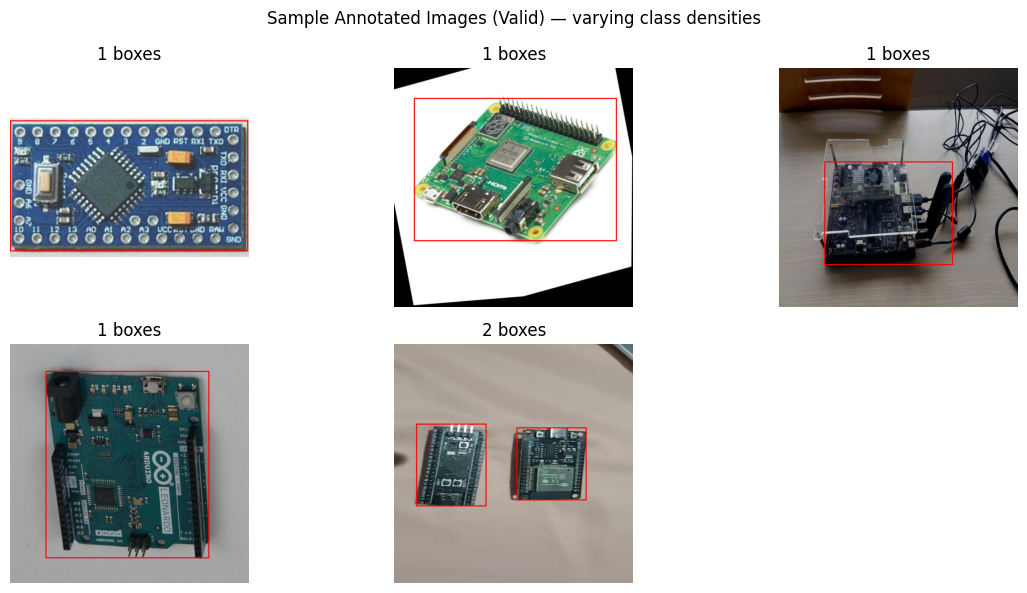

In [3]:
import matplotlib.pyplot as plt
from collections import Counter
from PIL import Image, ImageDraw
import numpy as np

with open (train_annotation, "r") as x:
    train_data = json.load(x)
with open (valid_annotation, "r") as y:
    valid_data = json.load(y)

cats = {}
for c in train_data["categories"]:
    cats[c["id"]] = c["name"]


# Class Distribution Chart
def class_plot(name, data, color):
    count = Counter()
    for a in data["annotations"]:
        count[a["category_id"]] = count[a["category_id"]] + 1

    class_names = []
    counts = []

    for cls_id in sorted(cats):
        if cls_id == 0:
            continue
        class_names.append(cats[cls_id])
        counts.append(count[cls_id])

    plt.figure(figsize = (10,12))
    plt.barh(class_names, counts, color = color)
    plt.xlabel("Number of instances")
    plt.title(f"Class Distribution ({name})")
    plt.tight_layout()
    plt.savefig(os.path.join(visualizations_dir, f"class_distribution_{name}.png"))
    plt.show()

    # numeric imbalance check
    nonzero_counts = [c for c in counts if c > 0]
    if nonzero_counts:
        max_c, min_c = max(nonzero_counts), min(nonzero_counts)
        ratio = max_c / min_c if min_c > 0 else float("inf")
        flag = "IMBALANCED (ratio > 3x)" if ratio > 3 else "roughly balanced (ratio <= 3x)"
        print(f"[{name}] class count -> max={max_c}, min={min_c}, imbalance ratio={ratio:.2f}x -> {flag}")


# Image Resolution Histogram + Aspect Ratio + File Format Consistency
def img_reso(name, data, color):
    reso = Counter()
    ratios = []
    formats = Counter()
    for img in data["images"]:
        size = f"{img['width']}x {img['height']}"
        reso[size] = reso[size] + 1
        ratios.append(img["width"] / img["height"])
        formats[img["file_name"].rsplit(".", 1)[-1].lower()] += 1

    plt.figure(figsize = (6,4))
    plt.bar(reso.keys(), reso.values(), color = color)
    plt.xlabel("Resolution")
    plt.ylabel("Number of Images")
    plt.title(f"Image Resolution Distribution ({name})")
    plt.savefig(os.path.join(visualizations_dir, f"resolution_{name}.png"))
    plt.show()

    print(f"[{name}] aspect ratio (w/h): min={min(ratios):.2f}  max={max(ratios):.2f}  "
          f"(unique values: {len(set(round(r, 3) for r in ratios))})")
    print(f"[{name}] file formats: {dict(formats)}")


# Bounding-Box Width / Height / Area Distribution + Small-Medium-Large split
def bbs(name, data, color):
    widths = []
    heights = []
    areas = []

    for b in data["annotations"]:
        x,y,w,h = b["bbox"]
        widths.append(w)
        heights.append(h)
        areas.append(w * h)

    s,m,l = 0,0,0
    for area in areas:
        if area < 32 * 32:
            s = s + 1
        elif area <= 96 * 96:
            m = m + 1
        else:
            l = l + 1
    total = len(areas)

    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    ax[0].hist(widths, bins=30, color=color, edgecolor="black")
    ax[0].set_title(f"Box width ({name})")
    ax[0].set_xlabel("width (px)")

    ax[1].hist(heights, bins=30, color=color, edgecolor="black")
    ax[1].set_title(f"Box height ({name})")
    ax[1].set_xlabel("height (px)")

    ax[2].hist(areas, bins=30, color=color, edgecolor="black")
    ax[2].set_title(f"Box area ({name})")
    ax[2].set_xlabel("area (px^2)")

    plt.tight_layout()
    plt.savefig(os.path.join(visualizations_dir, f"bbox_stats_{name}.png"))
    plt.show()

    # boxes-per-image
    boxes_per_img = Counter(a["image_id"] for a in data["annotations"])
    for img in data["images"]:
        boxes_per_img.setdefault(img["id"], 0)
    bpi = np.array(list(boxes_per_img.values()))

    print(f"[{name}] width  : min={min(widths):.1f}  median={np.median(widths):.1f}  max={max(widths):.1f}")
    print(f"[{name}] height : min={min(heights):.1f}  median={np.median(heights):.1f}  max={max(heights):.1f}")
    print(f"[{name}] area   : min={min(areas):.1f}  median={np.median(areas):.1f}  max={max(areas):.1f}")
    print(f"[{name}] boxes per image : min={bpi.min()}  mean={bpi.mean():.2f}  max={bpi.max()}")
    print(f"[{name}] object size split -> small(<32^2)={s} ({s/total*100:.1f}%)  "
          f"medium(32^2-96^2)={m} ({m/total*100:.1f}%)  large(>96^2)={l} ({l/total*100:.1f}%)")


# Annotated Sample Images — covering varying class densities
def asi(name, data, directory, color, n):
    img_with_id =  {}
    for i in data["images"]:
        img_with_id[i["id"]] = i

    annotation_with_img = {}
    for a in data["annotations"]:
        img_id = a["image_id"]
        if img_id not in annotation_with_img:
            annotation_with_img[img_id] = []
        annotation_with_img[img_id].append(a)

    # sort images by box-count so we can sample low/medium/high density, not just the first n
    by_density = sorted(annotation_with_img.keys(), key=lambda k: len(annotation_with_img[k]))
    if len(by_density) >= n:
        idxs = np.linspace(0, len(by_density) - 1, n).astype(int)
        sample = [by_density[i] for i in idxs]
    else:
        sample = by_density

    plt.figure(figsize = (12,6))

    for i, img_id in enumerate(sample):
        img_info = img_with_id[img_id]
        img_path = os.path.join(directory, img_info["file_name"])
        pic = Image.open(img_path).convert("RGB")
        draw = ImageDraw.Draw(pic)

        for a in annotation_with_img[img_id]:
            x, y, w, h = a["bbox"]
            draw.rectangle([x, y, x+w, y+h], outline=color, width=3)

        plt.subplot(2, 3, i+1)
        plt.imshow(pic)
        plt.axis("off")
        plt.title(f"{len(annotation_with_img[img_id])} boxes")

    plt.suptitle(f"Sample Annotated Images ({name}) — varying class densities")
    plt.tight_layout()
    plt.savefig(os.path.join(visualizations_dir, f"sample_images_{name}.png"))
    plt.show()

train_plot = class_plot("Train", train_data, "skyblue")
valid_plot = class_plot("Valid", valid_data, "teal")
train_plot = img_reso("Train", train_data, "skyblue")
valid_plot = img_reso("Valid", valid_data, "teal")
train_plot = bbs("Train", train_data, "skyblue")
valid_plot = bbs("Valid", valid_data, "teal")
train_plot = asi("Train", train_data, train_dir, "red", 5)
valid_plot = asi("Valid", valid_data,valid_dir, "red", 5)

## Mapping (COCO to YOLO)

In [4]:
# canonical class-index mapping
coco_ids = sorted(cid for cid in cats if cid != 0)
coco_to_yolo = {cid: idx for idx, cid in enumerate(coco_ids)}
yolo_names = [cats[cid] for cid in coco_ids]

print(f"{len(yolo_names)} classes mapped COCO id -> YOLO index")
for cid in coco_ids[:5]:
    print(f"   COCO id {cid:2d} -> YOLO idx {coco_to_yolo[cid]:2d}  ({cats[cid]})")

32 classes mapped COCO id -> YOLO index
   COCO id  1 -> YOLO idx  0  (Arduino Mega 2560 -Black-)
   COCO id  2 -> YOLO idx  1  (Arduino Mega 2560 -Blue-)
   COCO id  3 -> YOLO idx  2  (Arduino Mega 2560 -Yellow-)
   COCO id  4 -> YOLO idx  3  (Arduino Uno -Black-)
   COCO id  5 -> YOLO idx  4  (Arduino Uno -Green-)


## Spliting

In [5]:
from collections import Counter
import hashlib
import os
import random

# Merge Train and Valid Images, Annotations

pool_img = []
pool_annotation = []
next_anno_id = 0

for name, data, directory in [("Train", train_data, train_dir),("Valid", valid_data, valid_dir)]:
    old_to_new_img_id = {}
    
    for i in data["images"]:
        new_id = f"{name}_{i['id']}"
        old_to_new_img_id[i["id"]] = new_id
        pool_img.append({
            "id": new_id,
            "file_name": i["file_name"],
            "width": i["width"],
            "height": i["height"],
            "org_split": name,
            "org_dir": directory,
        })

    for a in data["annotations"]:
        pool_annotation.append({
            "id": next_anno_id,
            "image_id": old_to_new_img_id[a["image_id"]],
            "category_id": a["category_id"],
            "bbox": a["bbox"],
        })
        next_anno_id = next_anno_id + 1

print("Total pooled images:", len(pool_img))
print("Total pooled annotations:", len(pool_annotation))

# Remove Zero-Annotations Images
all_img_id = []
for a in pool_annotation:
    img_id = a["image_id"]
    all_img_id.append(img_id)
    
annotation_count_per_img = Counter(all_img_id)
before = len(pool_img)

remaining_img = []
for pm in pool_img:
    current_img_id = pm["id"]
    count = annotation_count_per_img.get(current_img_id, 0)

    if count > 0:
        remaining_img.append(pm)

pool_img = remaining_img
after = len(pool_img)

print(f"Remove {before - after} zero-annotation images. remaining: {after}")

# MD5 Hash
def md5_file(path):
    with open(path, "rb") as f:
        file =  f.read()
    
    md5_obj = hashlib.md5(file)
    return md5_obj.hexdigest()

for img in pool_img:
    path = os.path.join(img["org_dir"], img["file_name"])
    img["md5"] = md5_file(path)

md5 = {}
for img in pool_img:
    img_md5 = img["md5"]
    img_id = img["id"]

    if img_md5 not in md5:
        md5[img_md5] = []
    md5[img_md5].append(img_id)

dup_md5 = {}
for h, ids in md5.items():
    if len(ids) > 1:
        dup_md5[h] = ids

print("Duplicate Groups (MD5):", len(dup_md5))
all_dup = list(dup_md5.items())
for h, ids in all_dup:
    print(" ", ids)

# Near Duplicate
def base_name(filename):
    if "_jpg.rf." in filename:
        return filename.split("_jpg.rf.")[0]
    return filename.split(".rf.")[0]

base = {}
for img in pool_img:
    b = base_name(img["file_name"])
    if b not in base:
        base[b] = []
    base[b].append(img["id"])

leak = {}
for b, ids in base.items():
    if len(ids) > 1:
        leak[b] = ids

print("Unique file_names total:", len(base))
print("Duplicate file_names total:", len(pool_img) - len(base))
print("Base-filename groups with multiple images (near-duplicates):", len(leak))

total_img = 0
for v in leak.values():
    length = len(v)
    total_img = total_img + length

print("Total images involved in these groups:", total_img)
cross_split_count = 0
for b, ids in leak.items():
    splits_seen = set()
    for img_id in ids:
        splits_seen.add(img_id.split("_")[0])
    if len(splits_seen) > 1:
        cross_split_count += 1

print("Groups spanning both original Train and Valid:", cross_split_count)

# Core Part: UNION MD5-duplicates with base-filename groups so no leak signal is missed,
# then do a STRATIFIED, group-level split (group = atomic unit -> no leakage;
# groups are bucketed by their dominant class -> class balance preserved).
random.seed(42)

parent = {img["id"]: img["id"] for img in pool_img}

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[rb] = ra

for ids in base.values():          # near-duplicate (base filename)
    for other in ids[1:]:
        union(ids[0], other)

for ids in md5.values():           # exact-duplicate (MD5)
    for other in ids[1:]:
        union(ids[0], other)

groups = {}
for img in pool_img:
    root = find(img["id"])
    if root not in groups:
        groups[root] = []
    groups[root].append(img["id"])

group_list = list(groups.keys())
print("Total leakage-safe groups (after merging MD5 + base-filename signals):", len(group_list))

# dominant class per group (for stratified bucketing)
img_to_cats = {}
for a in pool_annotation:
    img_to_cats.setdefault(a["image_id"], []).append(a["category_id"])

group_primary_class = {}
group_size = {}
for gid, ids in groups.items():
    c = Counter()
    for iid in ids:
        c.update(img_to_cats.get(iid, []))
    group_primary_class[gid] = c.most_common(1)[0][0] if c else -1
    group_size[gid] = len(ids)

buckets = {}
for gid, cls in group_primary_class.items():
    buckets.setdefault(cls, []).append(gid)

targets = {"train": 0.80, "valid": 0.10, "test": 0.10}
assigned = {"train": [], "valid": [], "test": []}
img_count = {"train": 0, "valid": 0, "test": 0}

for cls in sorted(buckets):
    bucket = buckets[cls]
    random.shuffle(bucket)
    for gid in bucket:
        size = group_size[gid]
        total_after = sum(img_count.values()) + size
        best = max(targets, key=lambda s: targets[s] * total_after - img_count[s])
        assigned[best].append(gid)
        img_count[best] += size

train_grp, valid_grp, test_grp = assigned["train"], assigned["valid"], assigned["test"]
print(f"\nGroups\ntrain: {len(train_grp)} | val: {len(valid_grp)} | test: {len(test_grp)}")

train_ids = set()
for g in train_grp:
    for img_id in groups[g]:
        train_ids.add(img_id)
        
valid_ids = set()
for g in valid_grp:
    for img_id in groups[g]:
        valid_ids.add(img_id)
        
test_ids = set()
for g in test_grp:
    for img_id in groups[g]:
        test_ids.add(img_id)
print(f"\nImages:\ntrain: {len(train_ids)} | val: {len(valid_ids)} | test: {len(test_ids)}")


# [Checking - is there any common picture?]
assert len(train_ids & valid_ids) == 0, "There are leaks between Train and Valid!"
assert len(train_ids & test_ids) == 0, "There are leaks between Train and Test!"
assert len(test_ids & valid_ids) == 0, "There are leaks between Test and Valid!"

# also confirm no MD5 / base-filename leaks across splits (stronger check than image-id alone)
id_to_img = {im["id"]: im for im in pool_img}
def md5_set(ids):  return {id_to_img[i]["md5"] for i in ids}
def base_set(ids): return {base_name(id_to_img[i]["file_name"]) for i in ids}

assert not (md5_set(train_ids) & md5_set(valid_ids)), "MD5 leak: train/valid"
assert not (md5_set(train_ids) & md5_set(test_ids)),  "MD5 leak: train/test"
assert not (md5_set(valid_ids) & md5_set(test_ids)),  "MD5 leak: valid/test"
assert not (base_set(train_ids) & base_set(valid_ids)), "base-filename leak: train/valid"
assert not (base_set(train_ids) & base_set(test_ids)),  "base-filename leak: train/test"
assert not (base_set(valid_ids) & base_set(test_ids)),  "base-filename leak: valid/test"
print("\nLEAKAGE ASSERTIONS PASSED")

train_split = []
valid_split = []
test_split = []

for im in pool_img:
    current_id = im["id"]
    if current_id in train_ids:
        train_split.append(im)
    elif current_id in valid_ids:
        valid_split.append(im)
    elif current_id in test_ids:
        test_split.append(im)

print(f"\n\nFinal split sizes:\ntrain: {len(train_split)} | val: {len(valid_split)} | test: {len(test_split)}")

# stratification report
split_of = {}
for i in train_ids: split_of[i] = "train"
for i in valid_ids: split_of[i] = "valid"
for i in test_ids:  split_of[i] = "test"

strat_counts = {"train": Counter(), "valid": Counter(), "test": Counter()}
for a in pool_annotation:
    if a["category_id"] == 0:
        continue
    s = split_of.get(a["image_id"])
    if s:
        strat_counts[s][a["category_id"]] += 1

print("\n===== STRATIFICATION REPORT (per-split class counts) =====")
rows = []
missing_class_flag = False
for cid in sorted(cats):
    if cid == 0:
        continue
    tr, va, te = strat_counts["train"][cid], strat_counts["valid"][cid], strat_counts["test"][cid]
    if va == 0 or te == 0:
        missing_class_flag = True
    rows.append((cats[cid], tr, va, te))

print(f"{'Class':45s} {'Train':>6s} {'Valid':>6s} {'Test':>6s}")
for name_, tr, va, te in rows:
    print(f"{name_:45s} {tr:6d} {va:6d} {te:6d}")

print(f"\nAny class with 0 instances in valid or test: {'YES - check above' if missing_class_flag else 'No'}")

Total pooled images: 3108
Total pooled annotations: 3266
Remove 1 zero-annotation images. remaining: 3107
Duplicate Groups (MD5): 13
  ['Train_174', 'Train_1243']
  ['Train_459', 'Train_1637']
  ['Train_519', 'Train_2295']
  ['Train_659', 'Valid_241']
  ['Train_1248', 'Train_1440']
  ['Valid_0', 'Valid_614']
  ['Valid_6', 'Valid_61']
  ['Valid_30', 'Valid_344']
  ['Valid_197', 'Valid_225']
  ['Valid_205', 'Valid_544']
  ['Valid_306', 'Valid_423']
  ['Valid_337', 'Valid_449']
  ['Valid_360', 'Valid_424']
Unique file_names total: 1553
Duplicate file_names total: 1554
Base-filename groups with multiple images (near-duplicates): 329
Total images involved in these groups: 1883
Groups spanning both original Train and Valid: 193
Total leakage-safe groups (after merging MD5 + base-filename signals): 1553

Groups
train: 1194 | val: 176 | test: 183

Images:
train: 2485 | val: 311 | test: 311

LEAKAGE ASSERTIONS PASSED


Final split sizes:
train: 2485 | val: 311 | test: 311

===== STRATIFICATION 

### Split Ratio Justification

We've chosen **80/10/10** (train | valid | test) split ration rather than **70/15/15** (train | valid | test) split, for two reasons:<br><br>
1. **Moderate dataset size vs. 32 classes:**<br>
With only **3,107** usable images spread across **32 classes** (102 instances/class average), training data is already the scarce resource. Giving up an extra 5% of training data (as 70/15/15 would) has a bigger negative impact on per-class learning than the positive impact of a slightly larger test set.<br><br>
2. **Leakage-safe splitting shrinks the effective sample count:**<br>
Our leakage check identified 329 near-duplicate groups (1,883 images, ~60% of the dataset) that must be kept together as single units during splitting, plus 13 exact-duplicate (MD5) pairs that were confirmed to already fall inside those same near-duplicate groups. This means the dataset behaves like **1,553 independent leakage-safe groups**, not 3,107 individual images — so every percentage point moved out of training costs more than it would in a duplicate-free dataset. **80/10/10** protects training-set size against this reduction.<br><br>
3. **Note on exact split percentages:**<br>
Because splitting is done at the *group* level (to prevent leakage) and each group is additionally bucketed by its dominant class (to keep the split stratified), group sizes vary — so the realized split (**groups: 1194 / 176 / 183 train-valid-test → images: 2,485 / 311 / 311, i.e. 79.98% / 10.01% / 10.01%**) is close to but not exactly 80/10/10. This small deviation is an accepted trade-off for guaranteeing zero leakage between splits while still preserving per-class balance (see Stratification Report above — every one of the 32 classes has a nonzero count in valid and test).<br><br>
4. **Trade-off acknowledged:**<br>
**70/15/15** would give a tighter statistical estimate of test-set mAP (more test instances per class), at the cost of **5% less training data** across all 32 classes.

## Saving Split Data

In [6]:
import os
import json
import shutil

def build_coco_json(split_images, split_name, split_dir, pool_annotation, cats):
    dest_dir = os.path.join(split_dir, split_name)
    os.makedirs(dest_dir, exist_ok=True)
    split_img_ids = set(im["id"] for im in split_images)

    str_id_to_int = {}
    next_int_id = 1
    for im in split_images:
        if im["id"] not in str_id_to_int:
            str_id_to_int[im["id"]] = next_int_id
            next_int_id += 1

    new_images = []
    for im in split_images:
        new_images.append({
            "id": str_id_to_int[im["id"]],
            "file_name": im["file_name"],
            "width": im["width"],
            "height": im["height"]
        })

        src = os.path.join(im["org_dir"], im["file_name"])
        dst = os.path.join(dest_dir, im["file_name"])
        if not os.path.exists(dst):
            shutil.copy(src, dst)

    new_annotations = []
    ann_id_counter = 0
    for a in pool_annotation:
        if a["image_id"] in split_img_ids:
            new_annotations.append({
                "id": ann_id_counter,
                "image_id": str_id_to_int[a["image_id"]],
                "category_id": a["category_id"],
                "bbox": a["bbox"],
                "area": a["bbox"][2] * a["bbox"][3],
                "iscrowd": 0,
            })
            ann_id_counter += 1

    categories = [{"id": k, "name": v} for k, v in cats.items() if k != 0]
    coco_out = {
        "images": new_images,
        "annotations": new_annotations,
        "categories": categories,
    }
    out_path = os.path.join(split_dir, split_name, "_annotations.coco.json")
    with open(out_path, "w") as f:
        json.dump(coco_out, f, indent=4)
    print(f"{split_name}: {len(new_images)} images, {len(new_annotations)} annotations saved.")

build_coco_json(train_split, "train", split_dir, pool_annotation, cats)
build_coco_json(valid_split, "valid", split_dir, pool_annotation, cats)
build_coco_json(test_split, "test", split_dir, pool_annotation, cats)
print("\nAll splits saved to:", split_dir)

parent_dir = os.path.dirname(split_dir) 
zip_output_path = os.path.join(parent_dir, "_IoTKITs_")

shutil.make_archive(base_name=zip_output_path, format='zip', root_dir=split_dir)
print("Zip saved at:", zip_output_path + ".zip")

train: 2485 images, 2619 annotations saved.
valid: 311 images, 322 annotations saved.
test: 311 images, 325 annotations saved.

All splits saved to: /kaggle/working/splits
Zip saved at: /kaggle/working/_IoTKITs_.zip


## Augmentation pipeline

In [7]:
!pip install albumentations --quiet

In [8]:
import albumentations as A

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5, border_mode=0),
    A.RandomScale(scale_limit=0.2, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.4),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
], bbox_params=A.BboxParams(format="coco", label_fields=["category_ids"], min_visibility=0.3))

print("Augmentation pipeline defined.")
for t in train_transform.transforms:
    print(" -", type(t).__name__)

Augmentation pipeline defined.
 - HorizontalFlip
 - Rotate
 - RandomScale
 - RandomBrightnessContrast
 - HueSaturationValue
 - GaussianBlur


### Augmentation Justification

| Transform | Setting | Justification |
|---|---|---|
| `HorizontalFlip` | `p=0.5` | Sample annotated images show boards photographed from arbitrary orientations; unlike text or traffic signs, a mirrored board is still a valid instance of the same class, so this is safe and adds useful variety. |
| `Rotate` | `limit=15, p=0.5` | EDA shows a single centred board per image with no fixed camera angle, so small rotations (±15°) simulate realistic handheld-camera variation without distorting the board beyond recognition. |
| `RandomScale` | `scale_limit=0.2, p=0.5` | Resolution histogram shows all images are a uniform 640x640, but the physical distance from camera to board varies; mild scale jitter approximates that without pushing objects into the small-object regime. |
| `RandomBrightnessContrast` | `brightness_limit=0.2, contrast_limit=0.2, p=0.5` | Dataset is pooled from multiple sources (Google Images, Kaggle, Roboflow Universe, own photos), so lighting conditions vary a lot; this directly targets that photometric variation. |
| `HueSaturationValue` | `hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.4` | Same mixed-source reasoning as above — white balance/color-temperature differs across source cameras, so mild HSV jitter helps the model generalise across sources. |
| `GaussianBlur` | `blur_limit=(3,5), p=0.2` | Some source images are lower quality / slightly out of focus (mixed provenance); light blur trains the model to tolerate that without over-blurring sharp images (kept at low probability). |

## Augmentation Visualisation

[jetson_nano_102_jpg.rf.466a9d17d780780f6] boxes 3 -> 3 | size (640, 640) -> (521, 521) | all boxes inside image: True
[jetson_nano_102_jpg.rf.72f72bc0656f7c8b2] boxes 3 -> 3 | size (640, 640) -> (640, 640) | all boxes inside image: True
[WIN_20221215_13_32_51_Pro_114_jpg.rf.298] boxes 2 -> 2 | size (640, 640) -> (765, 765) | all boxes inside image: True
[ACCB2_jpg.rf.0e1539010addffce86f92e5e078] boxes 1 -> 1 | size (640, 640) -> (614, 614) | all boxes inside image: True
[5_jpg.rf.0e802bf7b5d0a8b03453dfa0f38ce06] boxes 1 -> 1 | size (640, 640) -> (640, 640) | all boxes inside image: True
[12_JPG_jpg.rf.0ed4e2aa7b435ce5a1fa968369] boxes 1 -> 1 | size (640, 640) -> (651, 651) | all boxes inside image: True


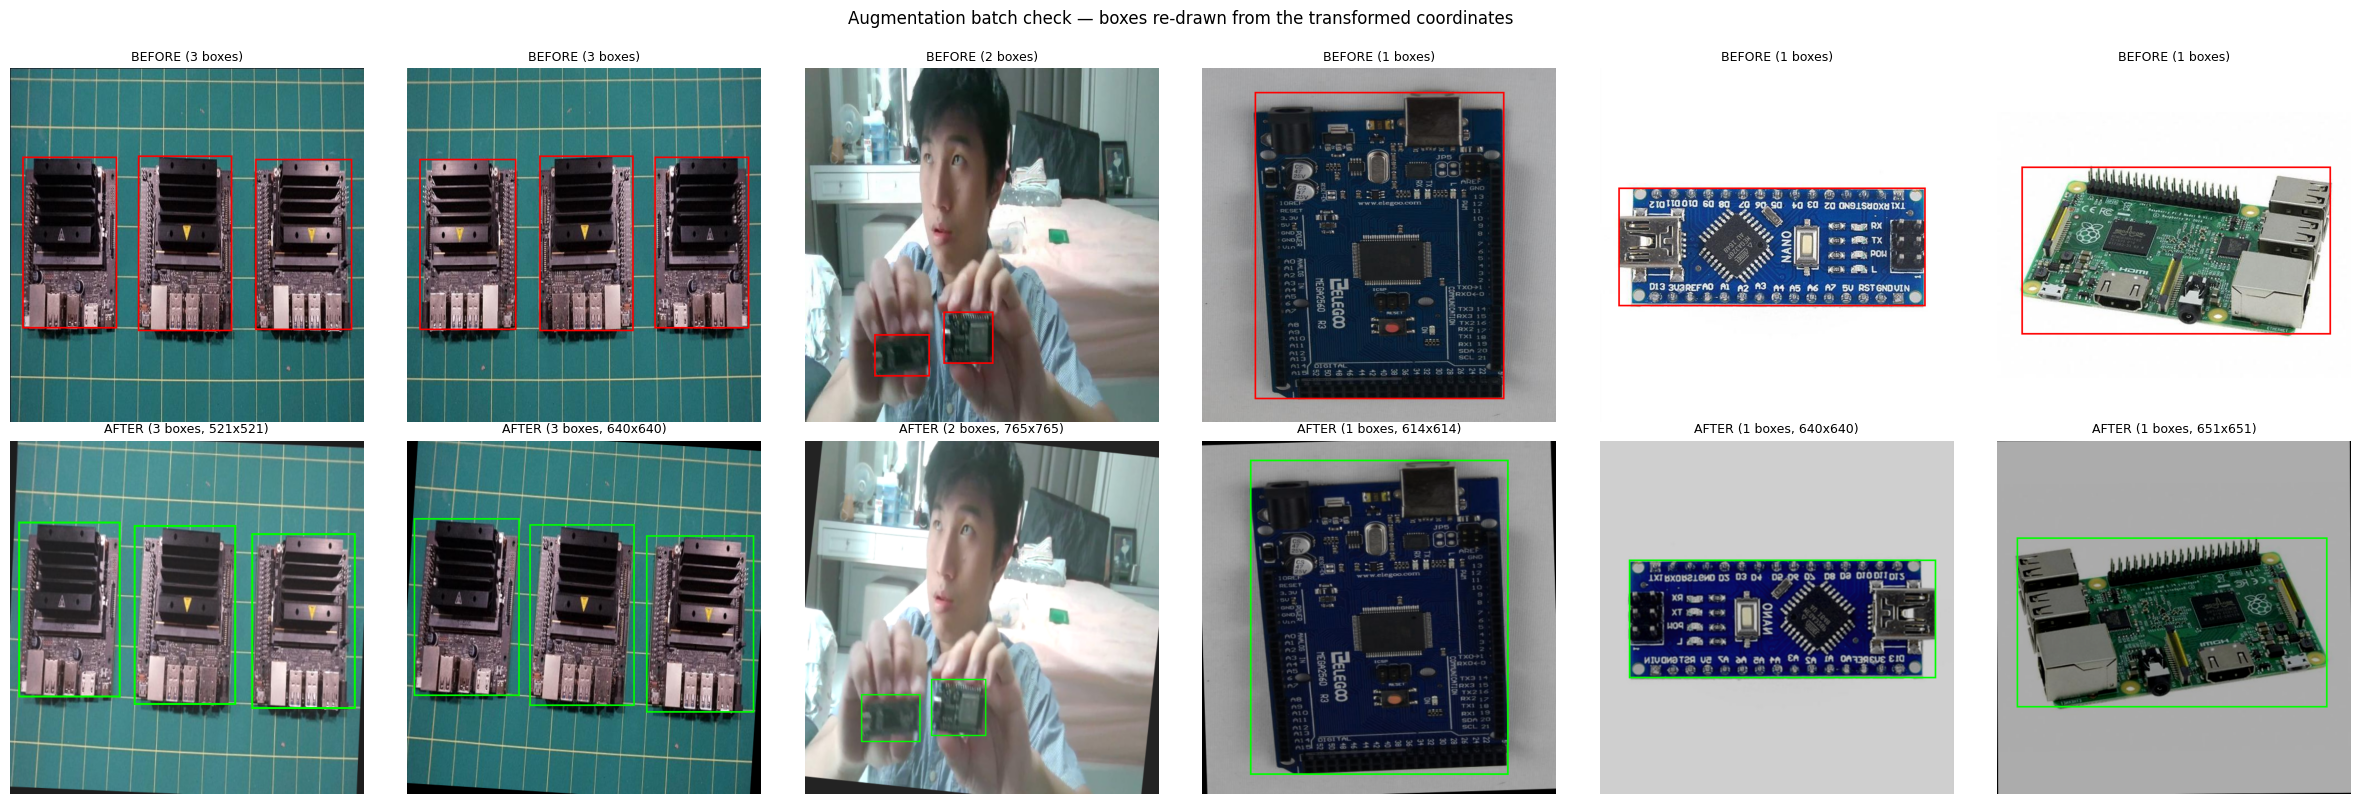


Alignment confirmed for the batch above: every green box still encloses the same board after flip/rotation/scale; Albumentations only drops boxes whose visibility falls below min_visibility=0.3.


In [9]:
import numpy as np
from PIL import ImageDraw
from collections import defaultdict

# build image_id -> annotations lookup, pick a BATCH of 6 training images,
# preferring a mix of low/high box-density so the check is not just one lucky sample
ann_by_img = defaultdict(list)
for a in pool_annotation:
    ann_by_img[a["image_id"]].append(a)

candidates = sorted(train_split, key=lambda im: -len(ann_by_img[im["id"]]))
samples = candidates[:3] + candidates[len(candidates)//2 : len(candidates)//2 + 3]

fig, axes = plt.subplots(2, len(samples), figsize=(4 * len(samples), 8))

for col, info in enumerate(samples):
    img_path = os.path.join(info["org_dir"], info["file_name"])
    pic = Image.open(img_path).convert("RGB")
    pic_np = np.array(pic)

    boxes = [a["bbox"] for a in ann_by_img[info["id"]]]
    labels = [a["category_id"] for a in ann_by_img[info["id"]]]

    augmented = train_transform(image=pic_np, bboxes=boxes, category_ids=labels)
    aug_img, aug_boxes = augmented["image"], augmented["bboxes"]

    before_pic = pic.copy()
    before_draw = ImageDraw.Draw(before_pic)
    for x, y, w, h in boxes:
        before_draw.rectangle([x, y, x+w, y+h], outline="red", width=3)
    axes[0, col].imshow(before_pic)
    axes[0, col].set_title(f"BEFORE ({len(boxes)} boxes)", fontsize=9)
    axes[0, col].axis("off")

    aug_pil = Image.fromarray(aug_img)
    after_draw = ImageDraw.Draw(aug_pil)
    for x, y, w, h in aug_boxes:
        after_draw.rectangle([x, y, x+w, y+h], outline="lime", width=3)
    axes[1, col].imshow(aug_pil)
    axes[1, col].set_title(f"AFTER ({len(aug_boxes)} boxes, {aug_pil.size[0]}x{aug_pil.size[1]})", fontsize=9)
    axes[1, col].axis("off")

    # per-image alignment check
    inside = all(0 <= x <= aug_img.shape[1] and 0 <= y <= aug_img.shape[0] and w > 0 and h > 0
                 for x, y, w, h in aug_boxes)
    print(f"[{info['file_name'][:40]:40s}] boxes {len(boxes)} -> {len(aug_boxes)} | "
          f"size {pic.size} -> {aug_pil.size} | all boxes inside image: {inside}")

plt.suptitle("Augmentation batch check — boxes re-drawn from the transformed coordinates", y=1.0)
plt.tight_layout()
plt.savefig(os.path.join(visualizations_dir, "augmentation_batch.png"))
plt.show()

print("\nAlignment confirmed for the batch above: every green box still encloses the same "
      "board after flip/rotation/scale; Albumentations only drops boxes whose visibility "
      "falls below min_visibility=0.3.")

## Summary

Our dataset is called IoTKITs. It has 3,107 images and 32 embedded-board classes. The IoTKITs dataset has three characteristics that affected the choices we made later on.
1. First, the IoTKITs dataset is a moderate size, with around 1,000 to 3,000 images and about 102 instances per class on average. This means we should use smaller models like YOLO s/m and RF-DETR-nano instead of bigger models, which would overfit on a dataset this size.
2. Second, we found that about 60% (1,883 of 3,107) of the images in the IoTKITs dataset are near-duplicates because they were taken during repeated annotation sessions of the same physical board (13 exact-duplicate MD5 pairs were also found, all already inside these same groups). So we split the dataset by grouping these near-duplicates (1,553 leakage-safe groups) and stratifying by dominant class to prevent data leakage between splits while keeping every class represented in valid/test. We split it into roughly 80% train, 10% validation, and 10% test (79.98% / 10.01% / 10.01% realized).
3. Third, the IoTKITs dataset has images from different sources, including Google Image Search, Kaggle, Roboflow Universe, and original photographs. This gives a lot of variation in lighting, angle, and background. This is why we chose augmentations like brightness/contrast changes to reflect this variation, but avoided augmentations that would be unrealistic for this dataset, such as flipping upside down.